In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
Data = pd.read_csv("ML-5 Outlier Removal 16952195440.txt")

In [4]:
Data

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [7]:
Data.isnull().any()

area_type       False
availability    False
location         True
size             True
society          True
total_sqft      False
bath             True
balcony          True
price           False
dtype: bool

In [5]:
Data.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


# Z SCORE  ( = (X - MEAN) /STD )

In [98]:
l = [29,10,45,46,68,34,65,89,400,92,77,66,69,65,80,77,21,37,42]

In [99]:
data = pd.DataFrame(l,columns=["Values"])

In [100]:
mean = data["Values"].mean()

In [101]:
mean

74.3157894736842

In [102]:
std = data["Values"].std()

In [103]:
std

82.23006521784471

array([[<Axes: title={'center': 'Values'}>]], dtype=object)

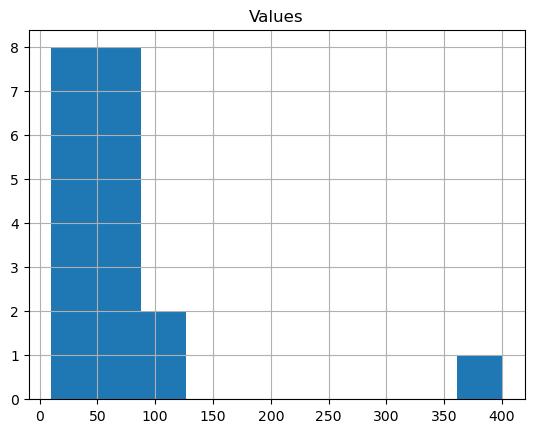

In [104]:
data.hist()

In [105]:
(data["Values"] - mean)/std

0    -0.551085
1    -0.782144
2    -0.356509
3    -0.344348
4    -0.076806
5    -0.490280
6    -0.113289
7     0.178575
8     3.960646
9     0.215058
10    0.032643
11   -0.101128
12   -0.064645
13   -0.113289
14    0.069126
15    0.032643
16   -0.648373
17   -0.453797
18   -0.392992
Name: Values, dtype: float64

In [106]:
data["Z_Score"] = (data["Values"] - mean)/std      


# find z score amd save it 

In [107]:
data

,Values,Z_Score
0,29,-0.551085
1,10,-0.782144
2,45,-0.356509
3,46,-0.344348
4,68,-0.076806
5,34,-0.490280
6,65,-0.113289
7,89,0.178575
8,400,3.960646
9,92,0.215058


# check outliers

In [108]:
 data[(data["Z_Score"]>3) | (data["Z_Score"]<-3)]

# for outliers
#use | or gate

,Values,Z_Score
8,400,3.960646


# for actual values

In [65]:
real_val = data[(data["Z_Score"]<3)&(data["Z_Score"]>-3)]

# for actual data

array([[<Axes: title={'center': 'Values'}>,
        <Axes: title={'center': 'Z_Score'}>]], dtype=object)

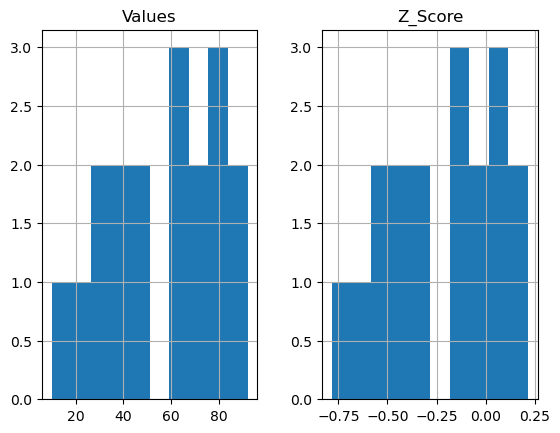

In [66]:
real_val.hist()

# 3 - div - std
# lower boundry = (mean - (3 * l.b))
# Upper boundry = (mean + (3 * u.b))

In [74]:
l = [29,10,45,46,68,34,65,89,400,92,77,66,69,65,80,77,21,37,42]

In [75]:
data = pd.DataFrame(l,columns=["Values"])

In [76]:
mean = data["Values"].mean()

In [77]:
std = data["Values"].std()

In [79]:
lower_boundry = mean - (3*std)

In [82]:
lower_boundry

-172.37440617984993

In [80]:
upper_boundry = mean + (3*std)

In [83]:
upper_boundry

321.00598512721837

In [85]:
data[(data["Values"]>upper_boundry)|(data["Values"]<lower_boundry)]

# for outliers

,Values
8,400


In [86]:
data[(data["Values"]<upper_boundry)|(data["Values"]>lower_boundry)]

# for actual values

,Values
0,29
1,10
2,45
3,46
4,68
5,34
6,65
7,89
8,400
9,92
